In [2]:
import h5py
import numpy as np

# Change this to the actual path if the file isn't in the same folder
file_path = 'quark-gluon_data-set_n139306.hdf5'

with h5py.File(file_path, 'r') as f:
    # This prints the keys in your file so we know where the images are
    print("Keys in HDF5 file:", list(f.keys()))
    
    # Usually, 'X' or 'all_jets' contains the images
    # Let's peek at the shape of the first dataset
    for key in f.keys():
        print(f"Shape of {key}:", f[key].shape)

Keys in HDF5 file: ['X_jets', 'm0', 'pt', 'y']
Shape of X_jets: (139306, 125, 125, 3)
Shape of m0: (139306,)
Shape of pt: (139306,)
Shape of y: (139306,)


In [4]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
class JetDataset(Dataset):
    def __init__(self, file_path, num_samples=20000):
        with h5py.File(file_path, 'r') as f:
            # 1. Load the raw data
            # Shape: (num_samples, 125, 125, 3)
            data = f['X_jets'][:num_samples]
            
            # 2. Convert to Torch Tensor and Permute
            # Moves channels to the front: (N, 3, 125, 125)
            self.X = torch.from_numpy(data).permute(0, 3, 1, 2).float()
            
            # 3. GLOBAL SCALING
            # We find the maximum value in the entire subset we just loaded
            dataset_max = self.X.max()
            
            if dataset_max > 0:
                self.X = self.X / dataset_max
                print(f"Normalization complete. Global Max was: {dataset_max.item():.4f}")
            else:
                print("Warning: Dataset max is 0. Check your data path!")

            # 4. Check results
            print(f"New Max: {self.X.max().item()} | New Min: {self.X.min().item()}")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

# Usage remains the same
file_path = 'quark-gluon_data-set_n139306.hdf5'
dataset = JetDataset(file_path)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

Normalization complete. Global Max was: 84.7784
New Max: 1.0 | New Min: 0.0


In [5]:
import torch.nn as nn

class ConvolutionalAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: Squeezes the image
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), 
            nn.ReLU(),
        )
        # Decoder: Reconstructs the image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=0), 
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=0),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # Force the output to be exactly 125x125
        return nn.functional.interpolate(x, size=(125, 125), mode='bilinear', align_corners=False)

# Check if GPU is available (Cuda) for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvolutionalAutoencoder().to(device)
print(f"Model is running on: {device}")

Model is running on: cpu


In [6]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.MSELoss() # Measures pixel-wise difference
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_autoencoder(epochs=10):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            output = model(batch)
            loss = criterion(output, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}")

# Let's run it for 10 epochs
train_autoencoder(epochs=10)

Epoch [1/10], Loss: 0.033908
Epoch [2/10], Loss: 0.000019
Epoch [3/10], Loss: 0.000006
Epoch [4/10], Loss: 0.000003
Epoch [5/10], Loss: 0.000002
Epoch [6/10], Loss: 0.000001
Epoch [7/10], Loss: 0.000001
Epoch [8/10], Loss: 0.000001
Epoch [9/10], Loss: 0.000000
Epoch [10/10], Loss: 0.000000


In [7]:
# Check how many pixels actually have data
sample = dataset.X[0]
non_zero_count = torch.count_nonzero(sample)
max_val = torch.max(sample)
mean_val = torch.mean(sample)

print(f"Non-zero pixels: {non_zero_count} out of {3*125*125}")
print(f"Max pixel value: {max_val.item()}")
print(f"Mean pixel value: {mean_val.item()}")

Non-zero pixels: 946 out of 46875
Max pixel value: 0.0029401183128356934
Mean pixel value: 6.488153303507715e-07


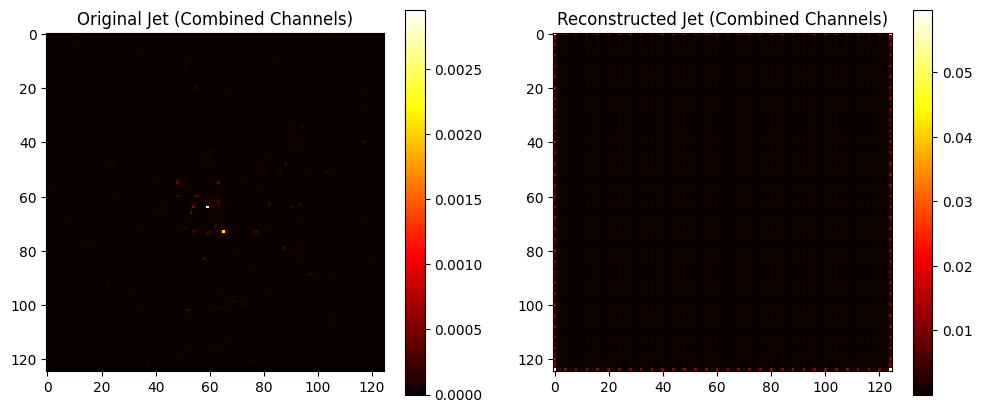

In [8]:
def show_comparison_v2():
    model.eval()
    with torch.no_grad():
        # Get sample 0
        orig = dataset.X[0].unsqueeze(0).to(device)
        recon = model(orig)
        
        # Sum the channels (Tracks + ECAL + HCAL) to see all hits at once
        orig_map = torch.sum(orig.cpu().squeeze(0), dim=0).numpy()
        recon_map = torch.sum(recon.cpu().squeeze(0), dim=0).numpy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Using 'hot' colormap and log-ish normalization to see sparse hits
    im1 = ax1.imshow(orig_map, cmap='hot', interpolation='nearest')
    ax1.set_title("Original Jet (Combined Channels)")
    plt.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(recon_map, cmap='hot', interpolation='nearest')
    ax2.set_title("Reconstructed Jet (Combined Channels)")
    plt.colorbar(im2, ax=ax2)
    
    plt.show()

show_comparison_v2()